# sliceheads — Compare Classification Heads

This notebook demonstrates how to train and evaluate **every classification head
in `sliceheads`** on the same embedding store — one `fit()` / `predict_proba()`
call per head, default hyperparameters, no tuning — and compare their test-set
performance side by side.

**You will:** load the full prepared embedding store, train each of the ten
built-in heads once with its conventional default settings, and compare their
held-out test metrics.


## Installation

Install the released package:


In [1]:
# Released version:
# %pip install sliceheads
# For local development instead, from the repo root:
# %pip install -e .


In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sliceheads.store import EmbedStore, validate_h5
from sliceheads.hpo import _pad_batch
from sliceheads.metrics import compute_metrics
from sliceheads.heads import (
    MeanPoolClassifier,
    MaxPoolClassifier,
    GeMPoolClassifier,
    ABMILClassifier,
    GatedABMILClassifier,
    DSMILClassifier,
    TransformerMILClassifier,
    MultiRocketHydraClassifier,
    InceptionTimeClassifier,
    ALSTMFCNClassifier,
)

print('sliceheads: classification-head comparison — ready')


sliceheads: classification-head comparison — ready


In [ ]:
# ---- Everything the notebook depends on is set here ----

H5_PATH = 'demo_output/prepared_embeddings.h5'   # built by prepare_hdf5_embeddings.ipynb
RANDOM_SEED = 42   # <- change this to use a different init seed (sliceheads.constants.DEFAULT_RANDOM_SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f'device: {DEVICE}')


## Input format

`H5_PATH` is an HDF5 store with one group per sample, written by
`sliceheads.store.EmbedStore`:

```
prepared_embeddings.h5
 ├── study_0001
 │    ├── embeddings: [num_slices, embedding_dim]   # e.g. [43, 768]
 │    └── attrs: label, split, patient_id
 └── ...
```

- **Source:** MosMedData-derived demo CT dataset, DINOv3 slice embeddings
  (see `prepare_hdf5_embeddings.ipynb`).
- **Labels:** binary — 0 = CT0 (no CT signs of pneumonia), 1 = CT12 (any involvement).
- **Split:** train / val / test, stored per sample as an attribute.


## Step 1 — Validate and load the data

`validate_h5` checks the schema; `EmbedStore.load_split` returns one
variable-length `[N_i, D]` array per sample, plus labels and sample IDs, for a
given split.


In [4]:
validate_h5(H5_PATH)
print('Validation passed ✓')

store = EmbedStore(H5_PATH)
emb_train, y_train, ids_train = store.load_split('train')
emb_val,   y_val,   ids_val   = store.load_split('val')
emb_test,  y_test,  ids_test  = store.load_split('test')

embedding_dim = emb_train[0].shape[1]

print(f'\nSplit sizes   : train={len(emb_train)}  val={len(emb_val)}  test={len(emb_test)}')
print(f'embedding_dim : {embedding_dim}')
for split_name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'{split_name:<6} class balance: 0={int((y == 0).sum())}  1={int((y == 1).sum())}')


Validation passed ✓



Split sizes   : train=637  val=211  test=215
embedding_dim : 768
train  class balance: 0=152  1=485
val    class balance: 0=50  1=161
test   class balance: 0=52  1=163


## Step 2 — Pad to fixed-size batches

Every head consumes a padded tensor `X: [B, N_max, D]` plus a binary
`mask: [B, N_max]` (`1` = real slice, `0` = padding). `_pad_batch` builds both
from the variable-length embedding lists, independently per split.


In [5]:
X_train, mask_train = _pad_batch(emb_train)
X_val,   mask_val   = _pad_batch(emb_val)
X_test,  mask_test  = _pad_batch(emb_test)

print(f'X_train: {X_train.shape}   mask_train: {mask_train.shape}')
print(f'X_val  : {X_val.shape}   mask_val  : {mask_val.shape}')
print(f'X_test : {X_test.shape}   mask_test : {mask_test.shape}')


X_train: (637, 67, 768)   mask_train: (637, 67)
X_val  : (211, 64, 768)   mask_val  : (211, 64)
X_test : (215, 57, 768)   mask_test : (215, 57)


## Step 3 — Construct every head with its default hyperparameters

Each head is instantiated with its own conventional defaults (e.g. `C=1.0` +
balanced class weights for the pooling heads, `lr=3e-4` + 100 max epochs with
early stopping for the neural heads) — no hyperparameter search. `device` and
`random_seed` are the only arguments passed explicitly, for reproducibility.


In [6]:
heads = {
    'MeanPoolClassifier': MeanPoolClassifier(random_seed=RANDOM_SEED),
    'MaxPoolClassifier': MaxPoolClassifier(random_seed=RANDOM_SEED),
    'GeMPoolClassifier': GeMPoolClassifier(random_seed=RANDOM_SEED),
    'ABMILClassifier': ABMILClassifier(device=DEVICE, random_seed=RANDOM_SEED),
    'GatedABMILClassifier': GatedABMILClassifier(device=DEVICE, random_seed=RANDOM_SEED),
    'DSMILClassifier': DSMILClassifier(device=DEVICE, random_seed=RANDOM_SEED),
    'TransformerMILClassifier': TransformerMILClassifier(device=DEVICE, random_seed=RANDOM_SEED),
    'MultiRocketHydraClassifier': MultiRocketHydraClassifier(random_seed=RANDOM_SEED),
    'InceptionTimeClassifier': InceptionTimeClassifier(device=DEVICE, random_seed=RANDOM_SEED),
    'ALSTMFCNClassifier': ALSTMFCNClassifier(device=DEVICE, random_seed=RANDOM_SEED),
}
print(f'{len(heads)} heads constructed with default hyperparameters')


10 heads constructed with default hyperparameters


## Step 4 — Train and evaluate each head (single run, no tuning)

For every head: `fit()` on the train split (with the val split passed through
for early stopping where the head uses it), then `predict_proba()` on the
held-out test split, then `compute_metrics()` for the full metric suite.


In [7]:
metrics_per_head = {}

for name, head in heads.items():
    print(f'Training {name} ...')
    head.fit(X_train, y_train, mask_train, X_val, y_val, mask_val)
    proba = head.predict_proba(X_test, mask_test)
    metrics_per_head[name] = compute_metrics(y_test, proba)
    print(f'  test ROC-AUC = {metrics_per_head[name]["roc_auc"]:.3f}')

print('\nDone.')


Training MeanPoolClassifier ...


  test ROC-AUC = 0.856
Training MaxPoolClassifier ...


  test ROC-AUC = 0.788
Training GeMPoolClassifier ...


  test ROC-AUC = 0.858
Training ABMILClassifier ...


  test ROC-AUC = 0.757
Training GatedABMILClassifier ...


...

  test ROC-AUC = 0.727
Training TransformerMILClassifier ...


  test ROC-AUC = 0.744
Training MultiRocketHydraClassifier ...


  test ROC-AUC = 0.566
Training InceptionTimeClassifier ...


  test ROC-AUC = 0.840
Training ALSTMFCNClassifier ...


  test ROC-AUC = 0.849

Done.


## Step 5 — Compare results

Test-set metrics for every head, sorted by ROC-AUC.


In [8]:
rows = []
for name, m in metrics_per_head.items():
    rows.append({
        'Head': name,
        'ROC-AUC': m['roc_auc'],
        '95% CI': f"[{m['roc_auc_ci_lower']:.3f}, {m['roc_auc_ci_upper']:.3f}]",
        'PR-AUC': m['pr_auc'],
        'Balanced Accuracy': m['balanced_accuracy'],
        'Sensitivity': m['sensitivity'],
        'Specificity': m['specificity'],
    })

df_results = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).set_index('Head')
df_results.round(3)


,ROC-AUC,95% CI,PR-AUC,Balanced Accuracy,Sensitivity,Specificity
Head,,,,,,
GeMPoolClassifier,0.858,"[0.793, 0.915]",0.941,0.818,0.828,0.808
MeanPoolClassifier,0.856,"[0.796, 0.910]",0.944,0.774,0.798,0.750
ALSTMFCNClassifier,0.849,"[0.791, 0.902]",0.948,0.744,0.853,0.635
InceptionTimeClassifier,0.840,"[0.777, 0.894]",0.942,0.724,0.853,0.596
MaxPoolClassifier,0.788,"[0.719, 0.853]",0.919,0.681,0.804,0.558
GatedABMILClassifier,0.764,"[0.686, 0.838]",0.899,0.716,0.779,0.654
ABMILClassifier,0.757,"[0.682, 0.829]",0.897,0.678,0.798,0.558
TransformerMILClassifier,0.744,"[0.660, 0.827]",0.872,0.695,0.718,0.673
DSMILClassifier,0.727,"[0.640, 0.809]",0.871,0.649,0.798,0.500


### Visualize ROC-AUC by head

A horizontal bar chart, sorted best-to-worst, with 95% bootstrap confidence
intervals as error bars.


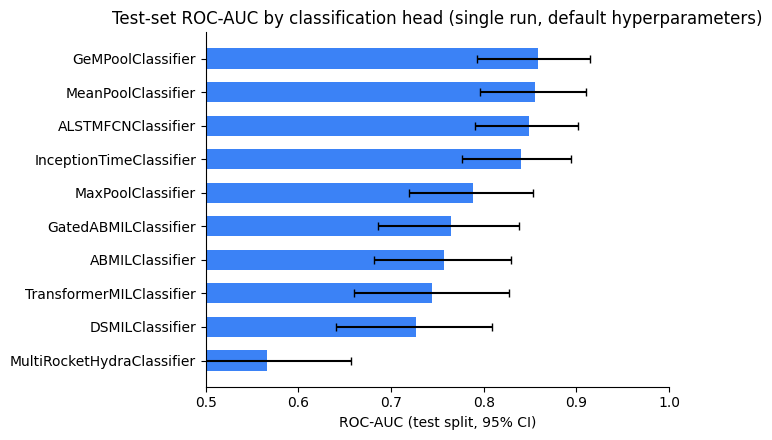

In [9]:
df_plot = df_results.sort_values('ROC-AUC')

fig, ax = plt.subplots(figsize=(7, 4.5))

lower_err = df_plot['ROC-AUC'] - df_plot['95% CI'].apply(lambda s: float(s.strip('[]').split(',')[0]))
upper_err = df_plot['95% CI'].apply(lambda s: float(s.strip('[]').split(',')[1])) - df_plot['ROC-AUC']

ax.barh(df_plot.index, df_plot['ROC-AUC'], xerr=[lower_err, upper_err],
        color='#3B82F6', edgecolor='none', height=0.6, capsize=3)
ax.set_xlabel('ROC-AUC (test split, 95% CI)')
ax.set_xlim(0.5, 1.0)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Test-set ROC-AUC by classification head (single run, default hyperparameters)')
plt.tight_layout()
plt.show()


## Results

Test-set metrics from this run (`train`=637, `val`=211, `test`=215 samples, DINOv3-B embeddings, single run, default hyperparameters, no tuning):

| Head | ROC-AUC | 95% CI | Balanced Accuracy | Sensitivity | Specificity |
|---|---|---|---|---|---|
| GeMPoolClassifier | 0.858 | [0.793, 0.915] | 0.818 | 0.828 | 0.808 |
| MeanPoolClassifier | 0.856 | [0.796, 0.910] | 0.774 | 0.798 | 0.750 |
| ALSTMFCNClassifier | 0.849 | [0.791, 0.902] | 0.744 | 0.853 | 0.635 |
| InceptionTimeClassifier | 0.840 | [0.777, 0.894] | 0.724 | 0.853 | 0.596 |
| MaxPoolClassifier | 0.788 | [0.719, 0.853] | 0.681 | 0.804 | 0.558 |
| GatedABMILClassifier | 0.764 | [0.686, 0.838] | 0.716 | 0.779 | 0.654 |
| ABMILClassifier | 0.757 | [0.682, 0.829] | 0.678 | 0.798 | 0.558 |
| TransformerMILClassifier | 0.744 | [0.660, 0.827] | 0.695 | 0.718 | 0.673 |
| DSMILClassifier | 0.727 | [0.640, 0.809] | 0.649 | 0.798 | 0.500 |
| MultiRocketHydraClassifier | 0.566 | [0.474, 0.657] | 0.552 | 0.699 | 0.404 |

Simple pooling (GeM, mean) matches or beats every neural MIL/time-series head here — unsurprising for a single untuned run, since the attention and sequence heads have far more hyperparameters (`lr`, `dropout`, architecture size) that default settings won't fit well for every dataset; `01_full_pipeline.ipynb` shows the same heads after HPO.


## Troubleshooting

- **FileNotFoundError on `H5_PATH`:** run `prepare_hdf5_embeddings.ipynb` first,
  or point `H5_PATH` at your own embedding store.
- **`validate_h5` raises "No samples with split='train'/'test'"**: the store
  needs at least one sample in each of the `train` and `test` splits.
- **CUDA not available:** `DEVICE` falls back to `'cpu'` automatically — the
  neural heads just train slower.
- **`MultiRocketHydraClassifier` ImportError:** this head needs `aeon`
  (`pip install aeon`); the other nine heads have no extra dependency.
- **Embedding-dimension mismatch:** all heads assume every sample in `H5_PATH`
  came from the same encoder (`embedding_dim` must match across samples).
- **Metrics look unstable / very different on rerun:** none of these heads were
  tuned — see `01_full_pipeline.ipynb` for HPO over head hyperparameters.


## Conclusion

In this notebook we loaded the full prepared embedding store, trained all ten
`sliceheads` classification heads once each with their default hyperparameters
using the `fit()` / `predict_proba()` API, and compared their held-out test
metrics side by side. To tune any of these heads instead of using defaults, see
`01_full_pipeline.ipynb`; to add a new head, see `02_add_a_head.ipynb`.
